<a href="https://colab.research.google.com/github/malexa41/retail-operations-profitability-analysis/blob/main/Retail_Operations_Intelligence_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retail Operations Intelligence Dashboard

## Project Overview

This project analyzes operational and financial performance for a national retail company experiencing declining profitability despite increasing sales volume.

The analysis investigates:

- shipping delays

- regional profitability

- product category performance

- discounting impacts

- fraud-related orders

- customer segment profitability

Tools used:

- Python

- Pandas

- Matplotlib

- Jupyter Notebook





## Business Problem

The executive operations team for a national retail company has noticed declining profitability despite increasing sales volume. Leadership wants a dashboard and analysis identifying operational inefficiencies, regional performance trends, shipping delays, and product categories impacting profit margins.

Primary objectives:
- Identify operational inefficiencies
- Investigate shipping performance and delivery delays
- Analyze profitability trends across regions and product categories
- Support executive decision-making through dashboards and KPI analysis

## Business Questions

- Why is profitability declining despite increasing sales volume?
- Are shipping delays negatively impacting profitability?
- Which regions generate the highest sales but weakest margins?
- Which product categories are most and least profitable?
- Does shipping mode influence late delivery risk?
- Are discounts reducing overall profitability?
- Are certain customer segments more profitable than others?
- Are fraud-related orders impacting operational performance?

## Hypotheses

- Higher discount rates may reduce profitability.
- Standard shipping may increase late delivery risk.
- Some regions may generate high sales but weak profit margins.
- Certain product categories may produce high sales volume but low profitability.
- Late deliveries may contribute to operational losses through returns, refunds, or customer dissatisfaction.
- Faster shipping methods may improve profitability enough to justify increased shipping costs.
- Fraud-related orders may negatively impact operational performance and profitability.

# Key Performance Indicators (KPIs)

The following KPIs were used throughout the analysis to evaluate operational and financial performance across the retail business.

## Financial KPIs
- Total Sales
- Average Profit Per Order
- Average Profit Ratio
- Order Profitability by Region
- Order Profitability by Product Category

## Operational KPIs
- Late Delivery Rate
- Shipping Performance by Shipping Mode
- Delivery Status Distribution

## Customer & Market KPIs
- Customer Segment Profitability
- Regional Margin Performance
- Product Category Performance

## Risk & Fraud KPIs
- Fraud-Related Order Activity
- Fraud vs Non-Fraud Financial Performance

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')

# Show basic info
print(df.shape)

# Show column names
print(df.columns)

# Preview dataset
df.head()

(21854, 53)
Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
      

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/15/2018 11:24,Standard Class


# Missing Value Analysis

Checking for missing data to identify potential data quality issues before analysis.

,0
Product Description,21854
Order Zipcode,19037
Product Status,1
shipping date (DateOrders),1
Shipping Mode,1
Product Price,1
Late_delivery_risk,0
Delivery Status,0
Category Name,0
Customer City,0


## Findings

- Product Description is entirely missing and may be removed.
- Order Zipcode has substantial missingness.
- Most operational fields appear complete.


# Dataset Structure Inspection

Inspecting the dataset structure to better understand:
- column data types
- missing values
- memory usage
- which fields are numerical vs categorical

This helps determine what cleaning and transformations may be needed before analysis.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21854 entries, 0 to 21853
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Type                           21854 non-null  object 
 1   Days for shipping (real)       21854 non-null  int64  
 2   Days for shipment (scheduled)  21854 non-null  int64  
 3   Benefit per order              21854 non-null  float64
 4   Sales per customer             21854 non-null  float64
 5   Delivery Status                21854 non-null  object 
 6   Late_delivery_risk             21854 non-null  int64  
 7   Category Id                    21854 non-null  int64  
 8   Category Name                  21854 non-null  object 
 9   Customer City                  21854 non-null  object 
 10  Customer Country               21854 non-null  object 
 11  Customer Email                 21854 non-null  object 
 12  Customer Fname                 21854 non-null 

## Findings

The dataset contains 21,854 records and 53 columns, indicating a large operational dataset suitable for business analytics and dashboarding.

Key observations:
- The dataset contains a mix of numerical and categorical variables.
- Numerical fields include sales, profit, shipping times, discounts, and quantities.
- Categorical fields include market, region, shipping mode, product category, and delivery status.
- Most columns are complete with very few missing values.
- `Product Description` contains no usable data and will likely be removed.
- `Order Zipcode` contains substantial missing data and may not be reliable for geographic analysis.
- Date columns are currently stored as object types and will likely need conversion to datetime format for time-series analysis.

# Duplicate Record Check

Checking for duplicate rows to identify whether the dataset contains repeated records that could distort analysis results and KPI calculations.

In [4]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

## Findings

No fully duplicated rows were found in the dataset.

This suggests that the dataset maintains record-level uniqueness and does not require duplicate row removal before analysis.



# Summary Statistics

Generating summary statistics for numerical columns to better understand the distribution, scale, and variability of key operational and financial metrics.

In [5]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,21854.000000,21854.000000,21854.000000,21854.000000,21854.000000,21854.000000,21854.000000,21854.000000,21854.000000,21854.000000,...,21854.000000,21854.000000,21854.000000,21854.000000,2817.000000,21854.000000,21854.000000,0.0,21853.000000,21853.0
mean,3.534822,2.963073,22.418360,185.557414,0.558387,26.292670,6957.063604,33300.514277,4.728883,28.912691,...,2.454105,206.716987,185.557414,22.418360,55182.955627,561.212684,26.292670,NaN,124.583556,0.0
std,1.594203,1.345962,111.578517,129.372449,0.496591,15.853168,4437.874313,37317.894617,1.611754,9.893825,...,1.587046,143.082927,129.372449,111.578517,31871.582910,325.075664,15.853168,NaN,141.394598,0.0
min,0.000000,0.000000,-3366.000000,8.470000,0.000000,2.000000,1.000000,603.000000,2.000000,17.982491,...,1.000000,11.290000,8.470000,-3366.000000,1453.000000,19.000000,2.000000,NaN,11.290000,0.0
25%,2.000000,2.000000,7.180000,103.989998,0.000000,17.000000,3326.500000,725.000000,4.000000,18.257663,...,1.000000,119.980003,103.989998,7.180000,22980.000000,365.000000,17.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.430000,156.759995,1.000000,24.000000,6721.000000,11372.000000,4.000000,32.642597,...,2.000000,179.970001,156.759995,31.430000,60540.000000,502.000000,24.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,66.000000,251.979996,1.000000,36.000000,10044.000000,75287.000000,5.000000,38.778381,...,4.000000,299.950012,251.979996,66.000000,89115.000000,642.000000,36.000000,NaN,129.990005,0.0
max,6.000000,4.000000,684.000000,1759.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1759.989990,684.000000,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


## Findings

Summary statistics show that the dataset includes meaningful financial and operational variation.

Key observations:
- Profit values include both gains and losses, with the lowest profit per order around -\$4,275.
- Sales vary widely, ranging from about \$10 to nearly \$2,000.
- Late delivery risk is stored as a binary variable, where 1 likely indicates late delivery risk and 0 indicates no late delivery risk.
- The average late delivery risk is about 0.55, meaning over half of records are flagged as at risk for late delivery.
- `Product Description` contains no usable values.
- `Product Status` appears to have no variation and may not be useful for analysis.


# Categorical Column Inspection

Inspecting key categorical columns to better understand the types of groups, labels, and operational categories present in the dataset.

This helps identify:
- regional groupings
- delivery statuses
- shipping methods
- customer segments
- product categories

In [6]:
categorical_columns = [
    'Market',
    'Order Region',
    'Delivery Status',
    'Shipping Mode',
    'Customer Segment',
    'Category Name',
    'Order Status'
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))


--- Market ---
Market
Europe          6065
LATAM           5873
Pacific Asia    5718
USCA            2923
Africa          1275
Name: count, dtype: int64

--- Order Region ---
Order Region
Western Europe     3282
Central America    3216
South America      1733
Oceania            1448
Southeast Asia     1324
Southern Europe    1161
Northern Europe    1144
South Asia         1119
Eastern Asia       1020
Caribbean           924
Name: count, dtype: int64

--- Delivery Status ---
Delivery Status
Late delivery        12203
Advance shipping      5024
Shipping on time      3849
Shipping canceled      778
Name: count, dtype: int64

--- Shipping Mode ---
Shipping Mode
Standard Class    13172
Second Class       4316
First Class        3431
Same Day            934
Name: count, dtype: int64

--- Customer Segment ---
Customer Segment
Consumer       11989
Corporate       6881
Home Office     2984
Name: count, dtype: int64

--- Category Name ---
Category Name
Cleats              4086
Women's Apparel  

## Findings

Inspection of categorical columns revealed several important operational patterns and potential business concerns.

Key observations:
- Late deliveries occur significantly more often than on-time deliveries, suggesting possible shipping or fulfillment inefficiencies.
- Standard Class is the most commonly used shipping method, which may contribute to delivery delays depending on fulfillment performance.
- The Consumer segment represents the largest customer segment in the dataset.
- Sales activity is concentrated heavily in LATAM and European markets.
- Several order statuses indicate operational issues, including canceled orders, payment review cases, on-hold orders, and suspected fraud cases.
- Product categories are unevenly distributed, with categories such as Cleats and Men’s Footwear appearing most frequently.

Potential business questions identified:
- Does shipping mode impact delivery delays and profitability?
- Are certain regions underperforming financially despite high sales volume?
- Do late deliveries contribute to reduced profit margins through returns, cancellations, or operational costs?
- Are some product categories generating high sales but low profit?



# Date Column Inspection

Inspecting the raw date columns to understand their formatting before converting them into datetime objects for time-series analysis.

In [7]:
# Preview date columns
df[['order date (DateOrders)', 'shipping date (DateOrders)']].head()

,order date (DateOrders),shipping date (DateOrders)
0,1/31/2018 22:56,2/3/2018 22:56
1,1/13/2018 12:27,1/18/2018 12:27
2,1/13/2018 12:06,1/17/2018 12:06
3,1/13/2018 11:45,1/16/2018 11:45
4,1/13/2018 11:24,1/15/2018 11:24


## Findings

The order and shipping date columns are currently stored as text values, but they appear to follow a consistent date-time format: month/day/year hour:minute.

These columns should be converted to datetime format so they can be used for:
- monthly sales and profit trends
- shipping time analysis
- order-to-shipment timelines
- time-based dashboard filters



# Datetime Conversion

Converting date columns from text format into datetime format so they can be used for time-series analysis, filtering, and trend calculations.

In [8]:
# Convert date columns to datetime
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

# Verify conversion
df[['order date (DateOrders)', 'shipping date (DateOrders)']].dtypes

,0
order date (DateOrders),datetime64[ns]
shipping date (DateOrders),datetime64[ns]


## Findings

The order and shipping date columns were successfully converted from object (text) format into datetime format.

This enables:
- time-series analysis
- date filtering
- trend analysis
- shipping duration calculations
- dashboard date controls



# Column Name Cleaning

Cleaning column names to improve readability and make the dataset easier to work with in Python, SQL, and visualization tools.

In [9]:
# Clean column names
df.columns = (
    df.columns
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
)

# Preview updated column names
df.columns

Index(['type', 'days_for_shipping_real', 'days_for_shipment_scheduled',
       'benefit_per_order', 'sales_per_customer', 'delivery_status',
       'late_delivery_risk', 'category_id', 'category_name', 'customer_city',
       'customer_country', 'customer_email', 'customer_fname', 'customer_id',
       'customer_lname', 'customer_password', 'customer_segment',
       'customer_state', 'customer_street', 'customer_zipcode',
       'department_id', 'department_name', 'latitude', 'longitude', 'market',
       'order_city', 'order_country', 'order_customer_id',
       'order_date_dateorders', 'order_id', 'order_item_cardprod_id',
       'order_item_discount', 'order_item_discount_rate', 'order_item_id',
       'order_item_product_price', 'order_item_profit_ratio',
       'order_item_quantity', 'sales', 'order_item_total',
       'order_profit_per_order', 'order_region', 'order_state', 'order_status',
       'order_zipcode', 'product_card_id', 'product_category_id',
       'product_descript

# Manual Column Renaming

Renaming a few overly long or awkward column names to improve readability while still preserving business meaning.

In [10]:
df = df.rename(columns={
    'order_date_dateorders': 'order_date',
    'shipping_date_dateorders': 'shipping_date',
    'order_item_product_price': 'item_product_price',
    'order_item_profit_ratio': 'item_profit_ratio',
    'order_item_quantity': 'item_quantity'
})

# Preview updated column names
df.columns

Index(['type', 'days_for_shipping_real', 'days_for_shipment_scheduled',
       'benefit_per_order', 'sales_per_customer', 'delivery_status',
       'late_delivery_risk', 'category_id', 'category_name', 'customer_city',
       'customer_country', 'customer_email', 'customer_fname', 'customer_id',
       'customer_lname', 'customer_password', 'customer_segment',
       'customer_state', 'customer_street', 'customer_zipcode',
       'department_id', 'department_name', 'latitude', 'longitude', 'market',
       'order_city', 'order_country', 'order_customer_id', 'order_date',
       'order_id', 'order_item_cardprod_id', 'order_item_discount',
       'order_item_discount_rate', 'order_item_id', 'item_product_price',
       'item_profit_ratio', 'item_quantity', 'sales', 'order_item_total',
       'order_profit_per_order', 'order_region', 'order_state', 'order_status',
       'order_zipcode', 'product_card_id', 'product_category_id',
       'product_description', 'product_image', 'product_name

# Dropping Unnecessary Columns

Removing columns that are irrelevant, unusable, or inappropriate for operational analytics and dashboarding.

In [11]:
# Drop unnecessary columns
df = df.drop(columns=[
    'product_description',
    'customer_password',
    'customer_email',
    'customer_fname',
    'customer_lname',
    'customer_street'
])

# Verify removal
df.columns

Index(['type', 'days_for_shipping_real', 'days_for_shipment_scheduled',
       'benefit_per_order', 'sales_per_customer', 'delivery_status',
       'late_delivery_risk', 'category_id', 'category_name', 'customer_city',
       'customer_country', 'customer_id', 'customer_segment', 'customer_state',
       'customer_zipcode', 'department_id', 'department_name', 'latitude',
       'longitude', 'market', 'order_city', 'order_country',
       'order_customer_id', 'order_date', 'order_id', 'order_item_cardprod_id',
       'order_item_discount', 'order_item_discount_rate', 'order_item_id',
       'item_product_price', 'item_profit_ratio', 'item_quantity', 'sales',
       'order_item_total', 'order_profit_per_order', 'order_region',
       'order_state', 'order_status', 'order_zipcode', 'product_card_id',
       'product_category_id', 'product_image', 'product_name', 'product_price',
       'product_status', 'shipping_date', 'shipping_mode'],
      dtype='object')

## Data Cleaning Summary

The following cleaning and preprocessing steps were performed before analysis:

- Converted date columns to datetime format
- Standardized column names for readability
- Removed irrelevant and sensitive customer fields
- Investigated missing values and duplicate records
- Created derived fields for:
  - discount buckets
  - fraud indicators
  - actual late delivery flags
- Validated shipping metrics against raw delivery outcomes

# Business Domains in Dataset

## Shipping / Logistics
- shipping_mode
- days_for_shipping_real
- delivery_status

## Sales / Revenue
- sales
- sales_per_customer
- order_item_total

## Profitability
- benefit_per_order
- order_profit_per_order
- item_profit_ratio

## Discounting
- order_item_discount
- order_item_discount_rate

## Customer
- customer_segment
- market
- customer_country

## Product
- product_name
- category_name
- product_price

## Geography
- order_region
- order_country
- latitude
- longitude



# EDA: Discount Rates vs Profitability

Investigating whether higher discount rates are associated with lower profitability.

Approach:
- Group discount rates into buckets
- Calculate average profit for each discount range
- Compare profitability trends across discount levels

In [12]:
# Create discount buckets
df['discount_bucket'] = pd.cut(
    df['order_item_discount_rate'],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 1],
    labels=['0%', '0-10%', '10-20%', '20-30%', '30%+']
)

# Calculate average profit by discount bucket
discount_profit = df.groupby('discount_bucket')['order_profit_per_order'].mean()

# Display results
discount_profit

/tmp/ipykernel_3774/1061239276.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_profit = df.groupby('discount_bucket')['order_profit_per_order'].mean()


,order_profit_per_order
discount_bucket,
0%,23.688802
0-10%,23.756730
10-20%,21.444983
20-30%,19.925455
30%+,NaN


## Visualization: Discount Rates vs Profitability

Creating a bar chart to compare average profit across discount rate buckets and visually evaluate the relationship between discounting and profitability.

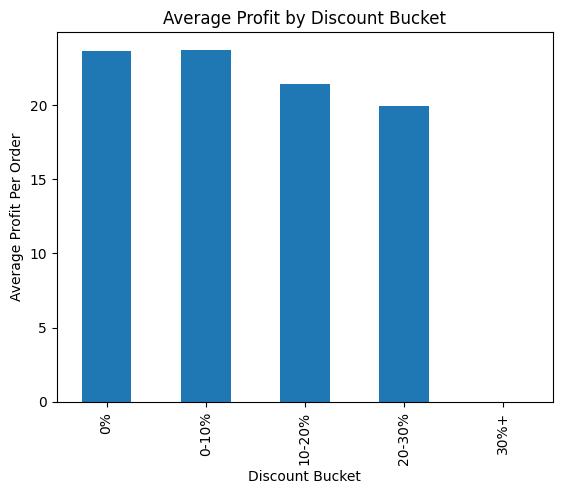

In [13]:
import matplotlib.pyplot as plt

# Create bar chart
discount_profit.plot(kind='bar')

# Add labels and title
plt.title('Average Profit by Discount Bucket')
plt.xlabel('Discount Bucket')
plt.ylabel('Average Profit Per Order')

# Show chart
plt.show()

## Findings

Analysis of discount buckets shows a negative relationship between discount rates and profitability.

Key observations:
- Orders with no discounts generated the highest average profit.
- Average profit declined consistently as discount rates increased.
- The results suggest that higher discounting may reduce overall profit margins.
- The decline in profitability appears gradual rather than extreme, indicating that discounts steadily erode margins over time.
- No observations appeared in the 30%+ discount bucket, suggesting either discounts rarely exceed 30% or additional investigation into the data distribution may be needed.

Initial conclusion:
The data currently supports the hypothesis that higher discount rates are associated with lower profitability.



# EDA: Shipping Mode vs Late Delivery Risk

Investigating whether certain shipping methods are associated with higher rates of late delivery risk.

Approach:
- Group orders by shipping mode
- Calculate the average late delivery risk for each shipping method
- Compare delivery risk rates across shipping categories

In [14]:
# Calculate late delivery risk rate by shipping mode
shipping_risk = df.groupby('shipping_mode')['late_delivery_risk'].mean()

# Display results
shipping_risk

,late_delivery_risk
shipping_mode,
First Class,0.980181
Same Day,0.543897
Second Class,0.775950
Standard Class,0.378302


## Note

Initial analysis used the `late_delivery_risk` column as a proxy for delivery performance because it is a binary variable suitable for rate calculations.

However, further inspection showed that this field represents delivery risk rather than confirmed late deliveries. Future analysis should instead use `delivery_status` to measure actual late delivery outcomes.



# EDA: Shipping Mode vs Actual Late Delivery Rate

Measuring actual late delivery outcomes using the `delivery_status` column instead of the risk flag.

Approach:
- Create a binary column where late delivery = 1 and all other delivery statuses = 0
- Group by shipping mode
- Calculate the percentage of late deliveries for each shipping method

In [15]:
# Create binary column for actual late deliveries
df['is_late_delivery'] = df['delivery_status'].eq('Late delivery').astype(int)

# Calculate actual late delivery rate by shipping mode
actual_late_rate = df.groupby('shipping_mode')['is_late_delivery'].mean().sort_values(ascending=False)

# Display results
actual_late_rate

,is_late_delivery
shipping_mode,
First Class,0.980181
Second Class,0.775950
Same Day,0.543897
Standard Class,0.378302


In [16]:
# Create a cross-tabulation table showing the count of each delivery status
# within each shipping mode.
#
# This helps validate whether the late delivery percentages calculated earlier
# are supported by the raw underlying counts.
#
# It also allows us to inspect how delivery outcomes differ across shipping methods.
pd.crosstab(df['shipping_mode'], df['delivery_status'])


delivery_status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
shipping_mode,,,,
First Class,0,3363,68,0
Same Day,0,508,14,412
Second Class,0,3349,94,873
Standard Class,5024,4983,602,2563


### Investigating Scheduled vs Actual Shipping Time

To better understand why some shipping methods experience higher late delivery rates, the analysis compares:

- average scheduled shipping time
- average actual shipping time

This helps determine whether late deliveries are caused by slower operational performance or by delivery expectations that are difficult to meet consistently.

In [17]:
# Group the dataset by shipping mode and calculate the average:
# - actual shipping time
# - scheduled shipping time
#
# This helps compare promised delivery speeds against actual performance
# for each shipping method.
#
# It also helps explain why certain shipping modes may have higher
# late delivery rates.
df.groupby('shipping_mode')[[
    'days_for_shipping_real',
    'days_for_shipment_scheduled'
]].mean()

,days_for_shipping_real,days_for_shipment_scheduled
shipping_mode,,
First Class,2.000000,1.0
Same Day,0.549251,0.0
Second Class,3.991659,2.0
Standard Class,3.996584,4.0


## EDA: Shipping Mode vs Actual Late Delivery Rate

Investigating whether certain shipping methods experience higher rates of actual late deliveries.

Approach:
- Create a binary late delivery indicator using the delivery_status column
- Group orders by shipping mode
- Calculate the percentage of orders delivered late for each shipping method
- Compare delivery performance across shipping categories

This analysis uses actual delivery outcomes rather than the late_delivery_risk field to better measure operational performance.

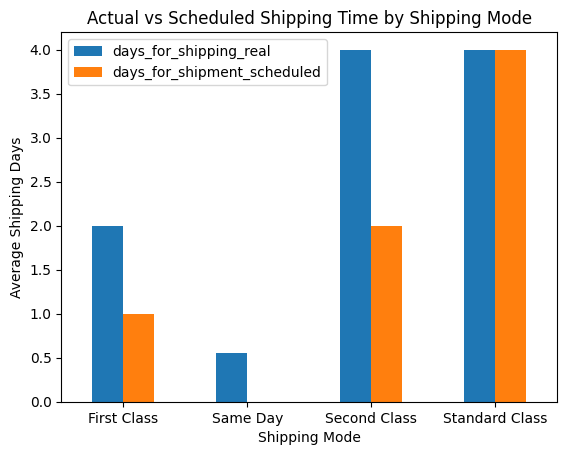

In [18]:
import matplotlib.pyplot as plt

# Calculate average actual and scheduled shipping times by shipping mode
shipping_times = df.groupby('shipping_mode')[[
    'days_for_shipping_real',
    'days_for_shipment_scheduled'
]].mean()

# Create grouped bar chart
shipping_times.plot(kind='bar')

# Add chart labels and title
plt.title('Actual vs Scheduled Shipping Time by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Shipping Days')

# Rotate x-axis labels for readability
plt.xticks(rotation=0)

# Display chart
plt.show()

## Findings

Actual late delivery rates vary strongly by shipping mode.

Key observations:
- First Class has the highest late delivery rate because it is scheduled for 1-day delivery but averages about 2 days in reality.
- Second Class also performs poorly because it is scheduled for 2-day delivery but averages about 4 days.
- Standard Class performs better because scheduled delivery time and actual delivery time are closely aligned.
- This suggests the issue may not be shipping speed alone, but unrealistic delivery promises for faster shipping methods.

Initial conclusion:
The data does not support the idea that Standard Class increases late delivery risk. Instead, faster shipping methods appear more likely to be marked late because their scheduled delivery windows are harder to meet.


## Analytical Notes

This analysis highlighted the importance of validating assumptions before drawing conclusions from metrics.

Initial analysis using the `late_delivery_risk` field suggested that First Class shipping performed significantly worse than Standard Class. Further investigation showed that the issue was driven by differences between scheduled delivery expectations and actual shipping times.

This demonstrates that operational metrics must be interpreted within business context rather than taken at face value.

# EDA: Regional Sales vs Profitability

Investigating whether some regions generate strong sales volume but weak profit margins.

Approach:
- Group data by region
- Calculate total sales
- Calculate total profit
- Calculate average profit ratio
- Compare operational performance across regions

In [19]:
# Calculate regional performance metrics
regional_performance = df.groupby('order_region').agg({
    'sales': 'sum',
    'order_profit_per_order': 'sum',
    'item_profit_ratio': 'mean'
}).sort_values(by='sales', ascending=False)

# Rename columns for readability
regional_performance.columns = [
    'total_sales',
    'total_profit',
    'avg_profit_ratio'
]

# Display results
regional_performance.head(10)

,total_sales,total_profit,avg_profit_ratio
order_region,,,
Western Europe,755034.462777,84216.070175,0.121222
Central America,663766.263068,68840.630061,0.116371
South America,350608.736562,41754.769886,0.129065
Oceania,299130.045664,25818.980150,0.112044
Southeast Asia,288270.014961,33246.469931,0.136186
Northern Europe,269292.434594,20705.120022,0.112675
Southern Europe,266975.084831,36378.980093,0.153936
South Asia,236653.104227,26758.660052,0.111072
Eastern Asia,228934.674350,19814.910073,0.098431


## Visualization: Regional Sales vs Profit Margin

Creating a scatter plot to compare total sales volume against average profit ratio across regions.

This helps identify:
- high-sales but low-margin regions
- lower-sales but highly profitable regions
- operational outliers

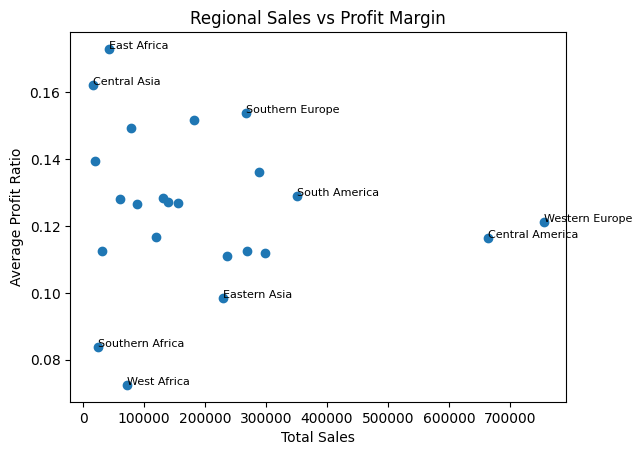

In [22]:
import matplotlib.pyplot as plt

# Create scatter plot
plt.scatter(
    regional_performance['total_sales'],
    regional_performance['avg_profit_ratio']
)

# Select important regions to label
top_sales = regional_performance.nlargest(3, 'total_sales').index
top_margin = regional_performance.nlargest(3, 'avg_profit_ratio').index
low_margin = regional_performance.nsmallest(3, 'avg_profit_ratio').index

# Combine all selected regions into one set
regions_to_label = set(top_sales) | set(top_margin) | set(low_margin)

# Add labels only for selected regions
for region, row in regional_performance.iterrows():

    if region in regions_to_label:

        plt.text(
            row['total_sales'],
            row['avg_profit_ratio'],
            region,
            fontsize=8
        )

# Add chart labels and title
plt.title('Regional Sales vs Profit Margin')
plt.xlabel('Total Sales')
plt.ylabel('Average Profit Ratio')

# Display plot
plt.show()

## Findings

Regional analysis shows that high sales volume does not always correspond to the strongest profit margins.

Key observations:
- Western Europe and Central America generated the highest total sales.
- Southern Europe and the Caribbean showed some of the strongest average profit ratios despite lower sales volume.
- Eastern Asia displayed relatively weaker profit margins compared to several other regions.
- The results suggest that some regions operate more efficiently and generate stronger profitability relative to revenue.
- East Africa and Central Asia demonstrated relatively low sales volume but strong profit margins, suggesting these regions may operate more efficiently or support more profitable sales activity.

Initial conclusion:
The analysis supports the hypothesis that some regions may produce strong sales while maintaining weaker profit margins compared to smaller but more profitable regions.

In [24]:
# Sort regions by lowest average profit ratio
lowest_margin_regions = regional_performance.sort_values(
    by='avg_profit_ratio',
    ascending=True
)

# Display lowest-margin regions
lowest_margin_regions.head(10)

,total_sales,total_profit,avg_profit_ratio
order_region,,,
West Africa,71904.641428,4261.810034,0.072463
Southern Africa,23894.500376,1203.809947,0.083893
Eastern Asia,228934.674350,19814.910073,0.098431
South Asia,236653.104227,26758.660052,0.111072
Oceania,299130.045664,25818.980150,0.112044
Central Africa,30868.800564,3138.219997,0.112473
Northern Europe,269292.434594,20705.120022,0.112675
Central America,663766.263068,68840.630061,0.116371
US Center,120191.632527,12989.840113,0.116676


## Additional Findings

Sorting regions by average profit ratio shows that West Africa and Southern Africa have the weakest profit margins in the dataset.

Key observations:
- West Africa has the lowest average profit ratio.
- Southern Africa has the second-lowest average profit ratio.
- Eastern Asia also shows weaker margins despite having much higher sales volume than both West Africa and Southern Africa.
- Central America and Western Europe have high sales volume, but their average profit ratios are not among the strongest.

Initial conclusion:
Leadership should investigate low-margin regions, especially West Africa, Southern Africa, and Eastern Asia, to determine whether profitability is being affected by pricing, discounting, shipping costs, product mix, or operational inefficiencies.



## Opportunities for Further Investigation

Several regions displayed unusually strong or weak profitability patterns and may warrant deeper operational analysis.

Regions of interest include:
- East Africa
- Central Asia
- Southern Africa
- West Africa
- Central America
- Western Europe

Potential areas for additional investigation include:
- regional discounting behavior
- shipping performance and delivery delays
- shipping mode distribution
- product category mix
- operational efficiency differences
- pricing strategy variations

Further analysis may help explain why some regions maintain strong profit margins despite lower sales volume, while others generate high sales with weaker profitability efficiency.

# EDA: Product Category Profitability

Investigating whether certain product categories generate stronger profitability than others.

Approach:
- Group data by product category
- Calculate total sales
- Calculate total profit
- Calculate average profit ratio
- Identify high-performing and low-performing categories

In [25]:
# Calculate product category performance metrics
category_performance = df.groupby('category_name').agg({
    'sales': 'sum',
    'order_profit_per_order': 'sum',
    'item_profit_ratio': 'mean'
}).sort_values(by='sales', ascending=False)

# Rename columns for readability
category_performance.columns = [
    'total_sales',
    'total_profit',
    'avg_profit_ratio'
]

# Display results
category_performance.head(10)

,total_sales,total_profit,avg_profit_ratio
category_name,,,
Cleats,803086.433887,83775.490125,0.120749
Cardio Equipment,699200.551027,70184.029675,0.112041
Camping & Hiking,595760.301846,59828.919692,0.111158
Women's Apparel,587950.000000,72017.240030,0.133783
Men's Footwear,421427.597831,47551.590257,0.126696
Fishing,371181.450208,39606.020473,0.120162
Shop By Sport,241491.293026,24139.680102,0.115548
Computers,127500.000000,9824.509965,0.088941
Sporting Goods,117006.750000,12518.610119,0.121064


In [26]:
# Sort categories by highest average profit ratio
highest_margin_categories = category_performance.sort_values(
    by='avg_profit_ratio',
    ascending=False
)

# Display top categories by profit margin
highest_margin_categories.head(10)

,total_sales,total_profit,avg_profit_ratio
category_name,,,
Baby,2008.720062,440.310006,0.247059
Music,16420.949616,3377.980012,0.226032
Consumer Electronics,16942.960328,3267.000006,0.215970
Soccer,6334.270005,1392.429974,0.212414
Fitness Accessories,7463.190078,1640.049998,0.197593
Kids' Golf Clubs,14069.259933,2412.159961,0.180980
Trade-In,11826.269885,1616.290010,0.175754
Crafts,37379.880891,5556.449973,0.160741
Strength Training,7867.939941,1379.999984,0.156667


In [28]:
# Sort categories by lowest average profit ratio
lowest_margin_categories = category_performance.sort_values(
    by='avg_profit_ratio',
    ascending=True
)

# Display top categories by profit margin
lowest_margin_categories.head(10)

,total_sales,total_profit,avg_profit_ratio
category_name,,,
Basketball,3799.919922,353.289990,-0.098750
As Seen on TV!,3999.600014,-273.449986,-0.031818
Men's Clothing,7379.750214,-79.729994,-0.012571
Books,1709.399996,64.249999,0.045636
Boxing & MMA,11945.820167,1124.730011,0.051017
Health and Beauty,12307.680357,634.760019,0.052143
Hunting & Shooting,9088.400012,1216.750014,0.069841
CDs,372.569999,26.080000,0.072424
DVDs,13314.780397,959.239994,0.086420


## Visualization: Product Category Sales vs Profit Margin

This scatter plot compares total sales volume against average profit ratio across product categories.

The visualization helps identify:
- high-sales categories with weaker margins
- low-sales categories with strong profitability
- categories operating at a loss
- potential growth opportunities and underperforming product segments

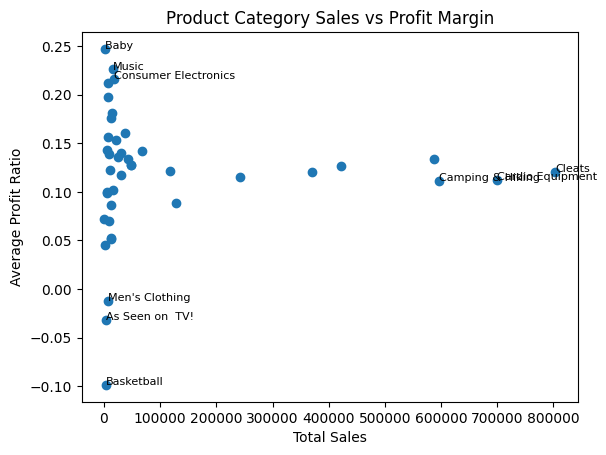

In [29]:
import matplotlib.pyplot as plt

# Create scatter plot
plt.scatter(
    category_performance['total_sales'],
    category_performance['avg_profit_ratio']
)

# Select categories to label
top_sales = category_performance.nlargest(3, 'total_sales').index
top_margin = category_performance.nlargest(3, 'avg_profit_ratio').index
low_margin = category_performance.nsmallest(3, 'avg_profit_ratio').index

# Combine selected categories
categories_to_label = set(top_sales) | set(top_margin) | set(low_margin)

# Add labels only for selected categories
for category, row in category_performance.iterrows():

    if category in categories_to_label:

        plt.text(
            row['total_sales'],
            row['avg_profit_ratio'],
            category,
            fontsize=8
        )

# Add labels and title
plt.title('Product Category Sales vs Profit Margin')
plt.xlabel('Total Sales')
plt.ylabel('Average Profit Ratio')

# Display plot
plt.show()

## Findings

Product category analysis shows that sales volume and profitability efficiency vary significantly across categories.

Key observations:
- Cleats, Cardio Equipment, and Camping & Hiking are major sales drivers.
- Electronics has lower sales volume among top-selling categories but a stronger average profit ratio.
- Baby, Music, and Consumer Electronics have the strongest profit ratios overall, though some have relatively low sales volume.
- Basketball, As Seen on TV!, and Men’s Clothing show the weakest profitability performance.
- Computers are especially worth investigating because they generate meaningful sales volume but have relatively weak profit margins.

Initial conclusion:
The data supports the hypothesis that certain product categories may generate high sales volume without strong profitability, while some lower-volume categories may be more margin-efficient.



# EDA: Delivery Outcomes vs Profitability

Investigating whether delivery performance is associated with changes in profitability.

Approach:
- Group orders by delivery status
- Compare average profit per order across delivery outcomes
- Evaluate whether late or canceled deliveries are associated with weaker financial performance

In [30]:
# Calculate average profit by delivery status
delivery_profit = df.groupby('delivery_status')[
    'order_profit_per_order'
].mean().sort_values()

# Display results
delivery_profit

,order_profit_per_order
delivery_status,
Late delivery,21.330475
Shipping on time,23.283300
Advance shipping,23.893049
Shipping canceled,25.679871


## Additional Investigation

Initial results showed that canceled shipments had the highest average profit per order, which appears operationally unusual.

To better understand this result, additional summary statistics were calculated to:
- compare the number of orders in each delivery status category
- evaluate median profit alongside average profit
- identify whether extreme outliers may be influencing the averages

This helps determine whether the observed profitability patterns are consistent across orders or potentially distorted by unusually large profit values.

In [31]:
# Compare count, mean, and median profit by delivery status
delivery_profit_summary = df.groupby('delivery_status')['order_profit_per_order'].agg(
    order_count='count',
    avg_profit='mean',
    median_profit='median',
    min_profit='min',
    max_profit='max'
).sort_values(by='avg_profit', ascending=False)

delivery_profit_summary

,order_count,avg_profit,median_profit,min_profit,max_profit
delivery_status,,,,,
Shipping canceled,778,25.679871,43.170000,-964.950012,235.179993
Advance shipping,5024,23.893049,32.075001,-3366.000000,599.250000
Shipping on time,3849,23.283300,30.490000,-1232.130005,613.349976
Late delivery,12203,21.330475,30.879999,-2550.000000,684.000000


## Visualization: Delivery Status vs Profitability

This bar chart compares the average profit per order across different delivery outcomes.

The visualization helps identify:
- whether late deliveries are associated with weaker profitability
- operational statuses linked to stronger or weaker financial performance
- unexpected profitability patterns that may require further investigation

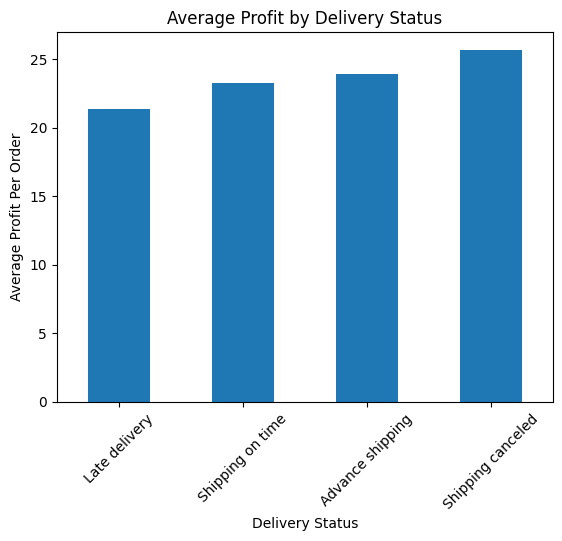

In [32]:
import matplotlib.pyplot as plt

# Calculate average profit by delivery status
delivery_profit_chart = df.groupby('delivery_status')[
    'order_profit_per_order'
].mean().sort_values()

# Create bar chart
delivery_profit_chart.plot(kind='bar')

# Add chart labels and title
plt.title('Average Profit by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Profit Per Order')

# Rotate labels for readability
plt.xticks(rotation=45)

# Display chart
plt.show()

## Findings

Further analysis shows that canceled shipments have the highest average and median profit, despite having the smallest number of orders.

Key observations:
- Shipping canceled has the fewest records, so results should be interpreted cautiously.
- The median profit for canceled shipments is also highest, suggesting the result is not caused only by extreme outliers.
- Late deliveries have the lowest average profit per order.
- All delivery outcomes include negative profit values, indicating losses occur across multiple operational statuses.

Initial conclusion:
Late deliveries appear associated with weaker profitability, but the relationship is not extreme. The unexpectedly strong profit performance for canceled shipments may require additional business context or further investigation into how cancellation status is defined in the dataset.



# EDA: Shipping Mode vs Profitability

Investigating whether faster shipping methods are associated with stronger profitability and profit efficiency.

Approach:
- Group orders by shipping mode
- Compare average profit per order
- Compare average profit ratio
- Evaluate whether faster shipping methods improve financial performance

In [33]:
# Calculate profitability metrics by shipping mode
shipping_profitability = df.groupby('shipping_mode').agg({
    'order_profit_per_order': 'mean',
    'item_profit_ratio': 'mean'
}).sort_values(by='order_profit_per_order', ascending=False)

# Rename columns for readability
shipping_profitability.columns = [
    'avg_profit_per_order',
    'avg_profit_ratio'
]

# Display results
shipping_profitability

,avg_profit_per_order,avg_profit_ratio
shipping_mode,,
First Class,24.248205,0.140396
Second Class,22.887382,0.128930
Standard Class,22.029904,0.117949
Same Day,18.974561,0.110439


## Visualization: Shipping Mode vs Average Profit Per Order

This chart compares the average profit generated per order across shipping methods.

The visualization helps identify:
- which shipping methods generate the strongest average profit
- whether faster shipping methods are associated with higher profitability

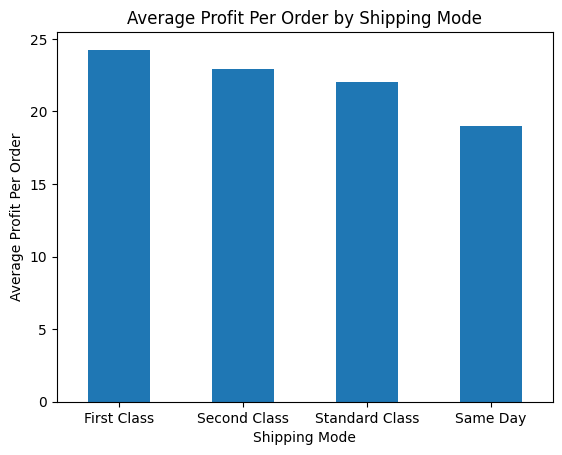

In [38]:
import matplotlib.pyplot as plt

# Plot average profit per order
shipping_profitability['avg_profit_per_order'].plot(kind='bar')

# Add labels and title
plt.title('Average Profit Per Order by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Profit Per Order')

# Rotate labels
plt.xticks(rotation=0)

# Display chart
plt.show()

## Visualization: Shipping Mode vs Profit Ratio

This chart compares average profit efficiency across shipping methods.

The visualization helps identify:
- which shipping methods maintain stronger margins
- whether faster shipping methods are associated with greater profit efficiency

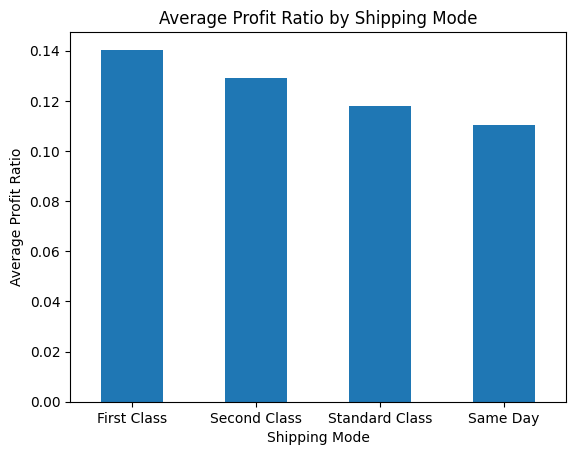

In [39]:
# Plot average profit ratio
shipping_profitability['avg_profit_ratio'].plot(kind='bar')

# Add labels and title
plt.title('Average Profit Ratio by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Profit Ratio')

# Rotate labels
plt.xticks(rotation=0)

# Display chart
plt.show()

## Findings

Shipping profitability varies by shipping mode.

Key observations:
- First Class has the highest average profit per order and highest average profit ratio.
- Second Class also outperforms Standard Class on both profitability measures.
- Standard Class performs moderately but does not generate the strongest profit efficiency.
- Same Day shipping has the lowest average profit and lowest profit ratio.

Initial conclusion:
The data partially supports the hypothesis that faster shipping methods may improve profitability. However, Same Day shipping does not follow this pattern and may involve higher operational costs, lower-margin orders, or other factors that reduce profitability.



# EDA: Fraud-Related Orders and Operational Performance

Investigating whether suspected fraud orders are associated with weaker operational or financial performance.

Approach:
- Examine order status categories
- Identify fraud-related order statuses
- Compare fraud-related orders against non-fraud orders
- Evaluate potential impacts on profitability and operations

In [34]:
df['order_status'].value_counts()

,count
order_status,
COMPLETE,7858
CLOSED,4312
PENDING_PAYMENT,3330
PROCESSING,2216
PENDING,1947
ON_HOLD,1245
SUSPECTED_FRAUD,414
CANCELED,364
PAYMENT_REVIEW,168


## Fraud Flag Creation

To simplify fraud analysis, a binary fraud flag was created:
- 1 = suspected fraud order
- 0 = non-fraud order

This allows fraud-related orders to be compared more easily against normal operational activity.

In [35]:
# Create binary fraud flag
df['is_fraud'] = df['order_status'].eq('SUSPECTED_FRAUD').astype(int)

# Check counts
df['is_fraud'].value_counts()

,count
is_fraud,
0,21440
1,414


## Fraud vs Non-Fraud Financial Comparison

Comparing suspected fraud orders against non-fraud orders to evaluate whether fraud-related transactions differ in sales value, profit, or margin efficiency.

Metrics compared:
- average sales
- average profit per order
- average profit ratio

In [36]:
# Compare financial metrics for fraud vs non-fraud orders
fraud_financial_summary = df.groupby('is_fraud').agg({
    'sales': 'mean',
    'order_profit_per_order': 'mean',
    'item_profit_ratio': 'mean'
})

# Rename index for readability
fraud_financial_summary.index = ['Non-Fraud', 'Suspected Fraud']

# Rename columns for readability
fraud_financial_summary.columns = [
    'avg_sales',
    'avg_profit_per_order',
    'avg_profit_ratio'
]

fraud_financial_summary

,avg_sales,avg_profit_per_order,avg_profit_ratio
Non-Fraud,206.537831,22.330512,0.123199
Suspected Fraud,215.995051,26.967778,0.129831


## Visualization: Fraud vs Non-Fraud Average Sales

This chart compares average sales values between suspected fraud and non-fraud orders.

The visualization helps evaluate whether suspected fraud orders tend to involve larger transactions.

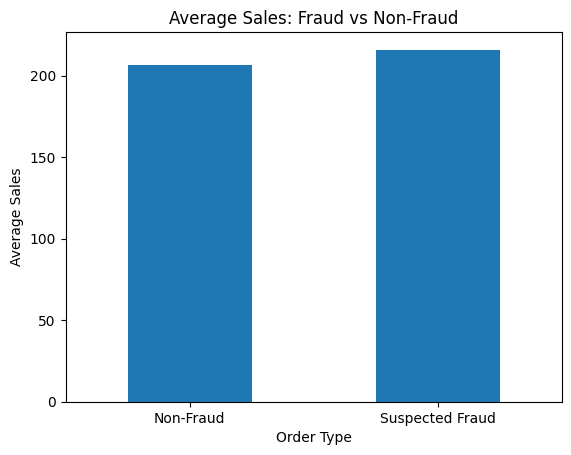

In [41]:
# Plot average sales
fraud_financial_summary['avg_sales'].plot(kind='bar')

# Add labels and title
plt.title('Average Sales: Fraud vs Non-Fraud')
plt.xlabel('Order Type')
plt.ylabel('Average Sales')

# Rotate labels
plt.xticks(rotation=0)

# Display chart
plt.show()

## Visualization: Fraud vs Non-Fraud Average Profit

This chart compares average profit per order between suspected fraud and non-fraud orders.

The visualization helps identify whether fraud-related orders are associated with weaker profitability.

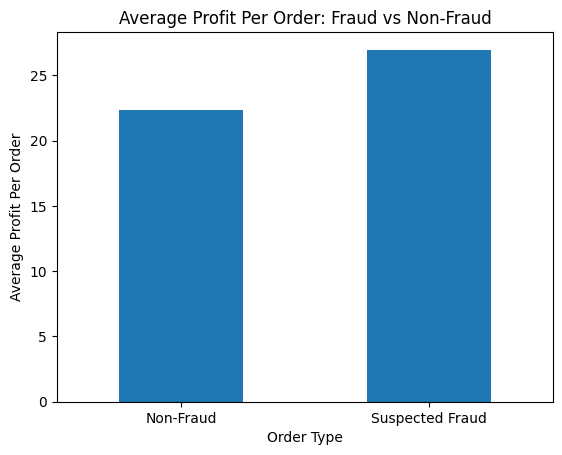

In [45]:
# Plot average profit per order
fraud_financial_summary['avg_profit_per_order'].plot(kind='bar')

# Add labels and title
plt.title('Average Profit Per Order: Fraud vs Non-Fraud')
plt.xlabel('Order Type')
plt.ylabel('Average Profit Per Order')

# Rotate labels
plt.xticks(rotation=0)

# Display chart
plt.show()

## Visualization: Fraud vs Non-Fraud Profit Ratio

This chart compares average profit efficiency between suspected fraud and non-fraud orders.

The visualization helps evaluate whether fraud-related orders differ in margin quality.

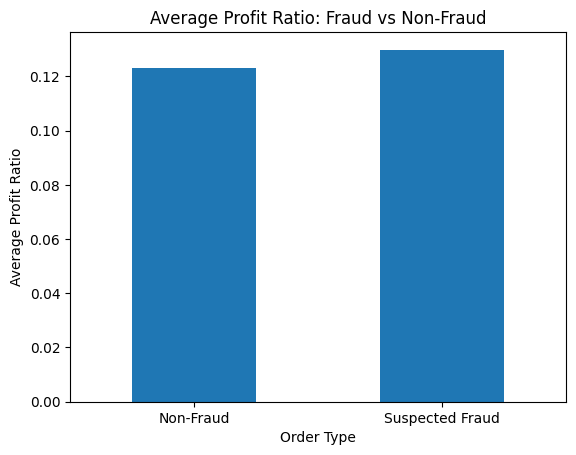

In [46]:
# Plot average profit ratio
fraud_financial_summary['avg_profit_ratio'].plot(kind='bar')

# Add labels and title
plt.title('Average Profit Ratio: Fraud vs Non-Fraud')
plt.xlabel('Order Type')
plt.ylabel('Average Profit Ratio')

# Rotate labels
plt.xticks(rotation=0)

# Display chart
plt.show()

## Findings

Initial fraud analysis does not show weaker financial performance for suspected fraud orders.

Key observations:
- Suspected fraud orders have higher average sales than non-fraud orders.
- Suspected fraud orders also show higher average profit per order and slightly higher average profit ratio.
- This does not necessarily mean fraud improves performance. The dataset may not capture downstream losses such as chargebacks, refunds, investigation costs, or inventory loss.

Initial conclusion:
The hypothesis that fraud-related orders negatively impact profitability is not supported by the available financial fields. Additional fraud outcome data would be needed to measure true financial impact.

# EDA: Customer Segment Profitability

Investigating whether certain customer segments generate stronger profitability and profit efficiency than others.

Approach:
- Group orders by customer segment
- Compare average sales
- Compare average profit per order
- Compare average profit ratio
- Identify high-value and high-efficiency customer segments

In [44]:
# Calculate customer segment profitability metrics
segment_profitability = df.groupby('customer_segment').agg({
    'sales': 'mean',
    'order_profit_per_order': 'mean',
    'item_profit_ratio': 'mean'
}).sort_values(by='order_profit_per_order', ascending=False)

# Rename columns for readability
segment_profitability.columns = [
    'avg_sales',
    'avg_profit_per_order',
    'avg_profit_ratio'
]

# Display results
segment_profitability

,avg_sales,avg_profit_per_order,avg_profit_ratio
customer_segment,,,
Consumer,217.643929,23.389207,0.120210
Corporate,191.832417,22.197295,0.131728
Home Office,197.138445,19.027493,0.116461


## Findings

Customer segment analysis shows that segment performance varies depending on whether the focus is sales volume, profit, or margin efficiency.

Key observations:
- Consumer customers generate the highest average sales and highest average profit per order.
- Corporate customers have the strongest average profit ratio, suggesting better margin efficiency.
- Home Office customers show the weakest profitability performance across the three segments.

Initial conclusion:
Consumer customers appear to drive stronger revenue and profit per order, while Corporate customers may be more efficient from a margin perspective.

# Executive Summary

This analysis investigated declining profitability within a national retail company despite continued sales growth. Using operational, financial, customer, and shipping data, the project explored relationships between sales performance, delivery operations, regional trends, product profitability, shipping methods, discounting, and fraud-related orders.

The analysis revealed that profitability challenges are driven by multiple operational and strategic factors rather than a single issue. Higher discount rates were associated with lower profit margins, several high-sales regions showed relatively weak profitability efficiency, and certain product categories generated substantial revenue while maintaining poor margins.

Shipping analysis showed that delivery performance varies significantly by shipping mode. Faster shipping methods, particularly First Class and Second Class, experienced higher late delivery rates because actual shipping times frequently exceeded promised delivery windows. However, faster shipping methods also generated stronger average profit performance overall.

Fraud-related orders did not demonstrate weaker financial performance within the dataset. Suspected fraud orders showed slightly higher average sales and profitability metrics, suggesting that additional operational context may be needed to fully interpret fraud-related activity.

Overall, the findings suggest that improving operational efficiency, refining pricing and discount strategies, and focusing on high-margin products and regions may help strengthen profitability performance.

# Key Findings

## Discounting and Profitability
- Higher discount rates were associated with lower average profit per order.
- Profitability steadily declined as discount levels increased.
- The analysis supports the hypothesis that aggressive discounting may erode profit margins over time.

## Shipping Performance and Delivery Delays
- First Class and Second Class shipping methods experienced the highest late delivery rates.
- Standard Class shipping showed better alignment between scheduled and actual delivery times.
- The issue appears to stem more from unrealistic delivery promises than shipping speed itself.

## Regional Performance
- Western Europe and Central America generated the highest total sales volumes.
- Southern Europe and the Caribbean demonstrated stronger profit efficiency despite lower sales volume.
- West Africa, Southern Africa, and Eastern Asia showed weaker average profit margins and may require additional operational review.

## Product Category Profitability
- Cleats, Cardio Equipment, and Camping & Hiking were major sales drivers.
- Baby, Music, and Consumer Electronics demonstrated the strongest profit margins.
- Basketball, As Seen on TV!, and Men’s Clothing showed weak or negative profitability performance.
- Some categories generated high sales volume without strong profit efficiency.

## Delivery Outcomes and Profitability
- Late deliveries were associated with the weakest average profit performance.
- Shipping canceled orders showed unexpectedly high profitability metrics and may require further business investigation.
- Operational inefficiencies may contribute to reduced financial performance.

## Shipping Mode and Profitability
- First Class shipping generated the highest average profit per order and strongest average profit ratio.
- Same Day shipping generated the weakest profitability metrics.
- Faster shipping methods may improve profitability, but not all expedited shipping options perform equally well.

## Fraud-Related Orders
- Suspected fraud orders represented a relatively small portion of the dataset.
- Fraud-related orders showed slightly higher average sales and profitability metrics than non-fraud orders.
- The analysis did not support the hypothesis that suspected fraud orders negatively impact profitability within this dataset.

# Business Recommendations

## Reevaluate Discounting Strategy
Leadership should review discounting practices, particularly in lower-margin regions and product categories. Reducing excessive discounts may help improve overall profitability performance.

## Improve Delivery Promise Accuracy
Shipping delays appear strongly tied to unrealistic delivery expectations for expedited shipping methods. Revising promised delivery windows may improve operational performance and customer satisfaction.

## Focus on High-Margin Product Categories
The company should prioritize growth strategies for categories demonstrating strong profitability efficiency, including Consumer Electronics, Music, and Fitness Accessories.

## Investigate Weak-Margin Regions
Regions such as West Africa, Southern Africa, and Eastern Asia may require operational review to identify factors contributing to weaker margins, including shipping costs, discounting behavior, or product mix.

## Review Same Day Shipping Operations
Same Day shipping generated the weakest profitability metrics and may involve operational costs that outweigh financial benefits. Leadership should evaluate pricing and fulfillment efficiency for this shipping mode.

## Further Investigate Fraud Classification
Fraud-related orders did not behave as expected financially. Additional investigation into fraud definitions, downstream losses, chargebacks, and operational impacts may provide more accurate insight.

# Recommended Next Steps

## Build Interactive Executive Dashboard
Develop a Tableau dashboard allowing leadership to monitor:
- sales trends
- profit margins
- shipping performance
- regional profitability
- customer segment performance
- fraud-related activity

## Expand Time-Series Analysis
Future analysis should investigate profitability trends over time to identify seasonal patterns, operational shifts, or long-term changes in performance.

## Perform Statistical Testing
Additional statistical analysis could strengthen findings by measuring:
- correlation between discounts and profitability
- significance of regional differences
- relationships between shipping delays and operational losses

## Develop Predictive Models
Future work could include predictive modeling to forecast:
- late delivery risk
- profitability trends
- fraud likelihood
- customer purchasing behavior

## Create Operational KPIs for Leadership Monitoring
Leadership dashboards should include ongoing KPI tracking for:
- late delivery rates
- average profit ratio
- discount efficiency
- regional margin performance
- shipping mode profitability